# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  # Import AdamW from torch.optim instead
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import random
import os
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

2025-06-08 09:05:24.004289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749373524.226328      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749373524.298841      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load the dataset


In [2]:
# Set seed for reproducibility
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed_value)

In [3]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [4]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [5]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [6]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [7]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [9]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


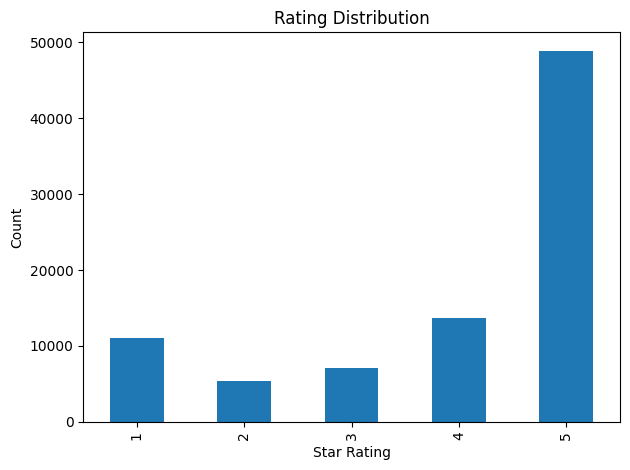

<Figure size 640x480 with 0 Axes>

In [10]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

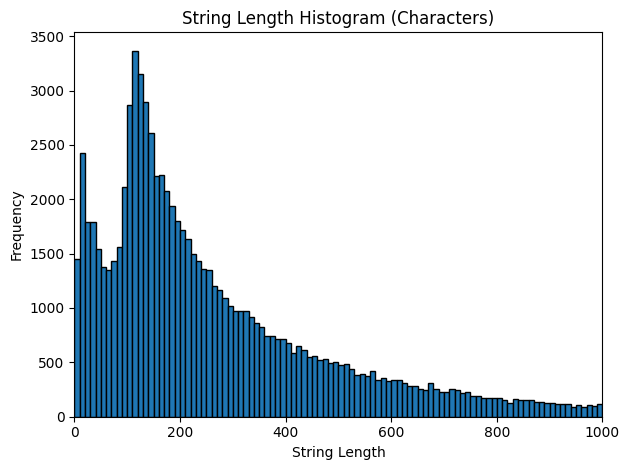

<Figure size 640x480 with 0 Axes>

In [11]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

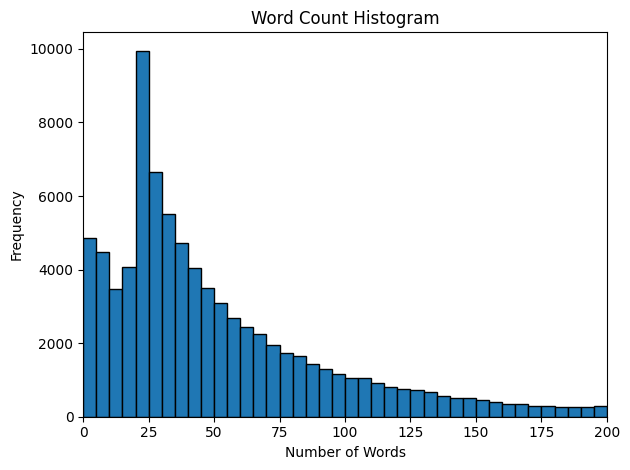

<Figure size 640x480 with 0 Axes>

In [12]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# 1. Data Preprocessing

# Drop rows with missing values


In [13]:
# Drop unnecessary columns
df = df[['star_rating', 'product_title', 'review_headline', 'review_body']]

# Drop rows with missing values
df.dropna(inplace=True)

# Convert star ratings to sentiment classes (0: Negative, 1: Positive)


In [14]:
# Convert star ratings to binary sentiment (0: Negative, 1: Positive)
df['sentiment'] = df['star_rating'].apply(lambda x: 0 if x <= 3 else 1)

# Combine 3 columns

In [15]:
# Combine product title, review headline, and review body
df['combined_text'] = df['product_title'] + " " + df['review_headline'] + " " + df['review_body']

# Print class distribution


In [16]:
# Label mapping
label_names = {0: "Negative", 1: "Positive"}

# Count occurrences in the full dataset
class_counts = np.bincount(df['sentiment'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")

Class Distribution (Full Dataset):
Negative: 23415 samples (27.25%)
Positive: 62504 samples (72.75%)


# View cleaned data

In [17]:
print("Sample of Cleaned Reviews with Labels:")
df[['star_rating', 'sentiment', 'combined_text']].sample(10, random_state=42)

Sample of Cleaned Reviews with Labels:


,star_rating,sentiment,combined_text
226,5,1,Viva Naturals #1 Best Selling Certified Organi...
71481,3,0,Clean + Easy Deluxe Home Electrolysis If you h...
72642,5,1,The Acuvibe Wireless Massager Amazing! I first...
11687,1,0,Personal Pedi Water Proof Electronic Hand and ...
71552,5,1,Denman Denman Styling Brush Heavy Weight 9 Row...
37974,5,1,Vktech Replacement Electric Toothbrush Heads P...
58155,4,1,"Lock Laces, Black Good For Those With Little T..."
39741,5,1,Oral-B Power Tip Replacement Electric Toothbru...
28511,2,0,Mega Motion Infinate Position Power Easy Comfo...
48480,5,1,"IQAir Pre-Filter Replacement for HealthPro, He..."


# 2. Tokenization and vocabulary


In [18]:
# Initialize BERT tokenizer (BertTokenizer as specified in the table)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Maximum sequence length (adjust if needed, but keep it reasonable to prevent overfitting)
MAX_LEN = 128

# Function to tokenize a text dataset
def tokenize_data(texts, tokenizer, max_len):
    input_ids = []
    attention_masks = []
    
    for text in tqdm(texts):
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

# Free up memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Tokenize the combined text
print("Tokenizing data...")
input_ids, attention_masks = tokenize_data(df['combined_text'].values, tokenizer, MAX_LEN)
labels = torch.tensor(df['sentiment'].values)

# Create a balanced dataset through sampling weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['sentiment'].values),
    y=df['sentiment'].values
)

print("Class weights:", class_weights)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizing data...


100%|██████████| 85919/85919 [01:59<00:00, 717.98it/s] 


Class weights: [1.83469998 0.68730801]


# 3. Split data: 70% train, 15% val, 15% test


In [19]:
# Create TensorDataset
dataset = TensorDataset(input_ids, attention_masks, labels)

# Split into training (70%), validation (15%), and test sets (15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

# Create random splits with fixed seeds for reproducibility
generator = torch.Generator().manual_seed(42)
train_dataset, temp_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size + test_size], generator=generator
)
val_dataset, test_dataset = torch.utils.data.random_split(
    temp_dataset, [val_size, test_size], generator=generator
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")


Training dataset size: 60143
Validation dataset size: 12887
Testing dataset size: 12889


# 4. Model & Custom Trainer


In [20]:
# Extract labels for the training set to create weights
train_labels = []
for i in range(len(train_dataset)):
    _, _, label = train_dataset[i]
    train_labels.append(label.item())

# Compute weights for balancing classes during training
samples_weight = torch.tensor([class_weights[label] for label in train_labels])
weighted_sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(train_dataset),
    replacement=True
)

# Batch size - smaller batch size may help prevent overfitting
batch_size = 16

# Create DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    sampler=weighted_sampler,  # Use the weighted sampler for balanced training
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=batch_size
)

# 5. Bert model


In [21]:
# Load BERT model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,  # Binary classification
    output_attentions=False,
    output_hidden_states=False,
)

# Add more dropout to reduce overfitting
model.config.hidden_dropout_prob = 0.3
model.config.attention_probs_dropout_prob = 0.3

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.to(device)

# MODIFIED: Set optimizer with learning rate 2e-5 as per table configuration
optimizer = AdamW(model.parameters(), 
                lr=5e-6,    # Lower learning rate 
                eps=1e-8,   # Small epsilon for numerical stability
                weight_decay=0.05  # L2 regularization to prevent overfitting
                )

# MODIFIED: Number of training epochs changed to 5 as per table configuration
epochs = 3

# Get total steps for scheduler
total_steps = len(train_dataloader) * epochs

# Create learning rate scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(0.1*total_steps),  # 10% of total steps for warmup
    num_training_steps=total_steps
)

# Early stopping parameters
best_val_loss = float('inf')
patience = 2
early_stop_counter = 0

# Function to format time
import time
import datetime
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round(elapsed))))

# Store training and validation statistics
training_stats = []

# Store losses and accuracies for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Store batch-level metrics for detailed plotting
batch_train_losses = []
batch_train_accuracies = []
batch_numbers = []
batch_counter = 0


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


# 6. Train and evaluate


In [22]:
# Training loop
print("Beginning training...")
total_training_time = 0

for epoch in range(epochs):
    print(f'\n======== Epoch {epoch + 1} / {epochs} ========')
    
    # Training
    print('Training...')
    start_time = time.time()
    
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0
    
    for step, batch in enumerate(tqdm(train_dataloader)):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        # Clear gradients
        model.zero_grad()
        
        # Forward pass
        outputs = model(
            b_input_ids, 
            attention_mask=b_input_mask, 
            labels=b_labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Accumulate loss
        total_train_loss += loss.item()
        
        # Calculate training accuracy
        preds = torch.argmax(logits, dim=1).flatten()
        accuracy = (preds == b_labels).cpu().numpy().mean()
        total_train_accuracy += accuracy
        
        # Store batch-level metrics (every 50 batches for plotting)
        if batch_counter % 50 == 0:
            batch_train_losses.append(loss.item())
            batch_train_accuracies.append(accuracy)
            batch_numbers.append(batch_counter // 50)
        
        batch_counter += 1
        
        # Backward pass
        loss.backward()
        
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update parameters
        optimizer.step()
        scheduler.step()
    
    # Training metrics
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_accuracy = total_train_accuracy / len(train_dataloader)
    
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)
    
    # Measure training time
    training_time = time.time() - start_time
    total_training_time += training_time
    
    print(f"Average training loss: {avg_train_loss:.4f}")
    print(f"Average training accuracy: {avg_train_accuracy:.4f}")
    print(f"Training epoch took: {format_time(training_time)}")
    
    # Validation
    print("\nRunning Validation...")
    
    model.eval()
    total_eval_loss = 0
    total_eval_accuracy = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(validation_dataloader):
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        with torch.no_grad():
            outputs = model(
                b_input_ids, 
                attention_mask=b_input_mask, 
                labels=b_labels
            )
        
        loss = outputs.loss
        logits = outputs.logits
        
        total_eval_loss += loss.item()
        
        # Calculate validation accuracy
        preds = torch.argmax(logits, dim=1).flatten()
        accuracy = (preds == b_labels).cpu().numpy().mean()
        total_eval_accuracy += accuracy
        
        # Store predictions and labels for metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())
    
    # Validation metrics
    avg_val_loss = total_eval_loss / len(validation_dataloader)
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)
    
    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Validation Accuracy: {avg_val_accuracy:.4f}")
    
    # Calculate validation metrics
    val_precision = precision_score(all_labels, all_preds, average='weighted')
    val_recall = recall_score(all_labels, all_preds, average='weighted')
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall: {val_recall:.4f}")
    print(f"Validation F1: {val_f1:.4f}")
    
    # Store stats for this epoch
    training_stats.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'train_accuracy': avg_train_accuracy,
        'val_accuracy': avg_val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'training_time': training_time,
    })
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pt')
        print("Best model saved!")
    else:
        early_stop_counter += 1
        print(f"Validation loss did not improve. Early stopping counter: {early_stop_counter}/{patience}")
        
    if early_stop_counter >= patience:
        print("Early stopping triggered!")
        break

print(f"\nTotal training time: {format_time(total_training_time)}")


Beginning training...

======== Epoch 1 / 3 ========
Training...


100%|██████████| 3759/3759 [24:30<00:00,  2.56it/s]


Average training loss: 0.2772
Average training accuracy: 0.8827
Training epoch took: 0:24:30

Running Validation...


100%|██████████| 806/806 [01:49<00:00,  7.36it/s]


Validation Loss: 0.2167
Validation Accuracy: 0.9305
Validation Precision: 0.9338
Validation Recall: 0.9305
Validation F1: 0.9314
Best model saved!

======== Epoch 2 / 3 ========
Training...


...

Average training loss: 0.1603
Average training accuracy: 0.9495
Training epoch took: 0:24:40

Running Validation...


100%|██████████| 806/806 [01:50<00:00,  7.28it/s]


Validation Loss: 0.2395
Validation Accuracy: 0.9317
Validation Precision: 0.9363
Validation Recall: 0.9316
Validation F1: 0.9328
Validation loss did not improve. Early stopping counter: 1/2

======== Epoch 3 / 3 ========
Training...


100%|██████████| 806/806 [01:50<00:00,  7.33it/s]s]

Validation Loss: 0.2273
Validation Accuracy: 0.9386
Validation Precision: 0.9402
Validation Recall: 0.9385
Validation F1: 0.9391
Validation loss did not improve. Early stopping counter: 2/2
Early stopping triggered!

Total training time: 1:13:48


# 8. Plot metrics


Training Summary Table:
Epoch  Training Loss   Validation Loss   Accuracy   F1         Precision    Recall    
1.0    0.277160        0.216693          0.930521   0.931401   0.933828     0.930473  
2.0    0.160312        0.239542          0.931684   0.932770   0.936304     0.931637  
3.0    0.134256        0.227299          0.938586   0.939069   0.940189     0.938543  


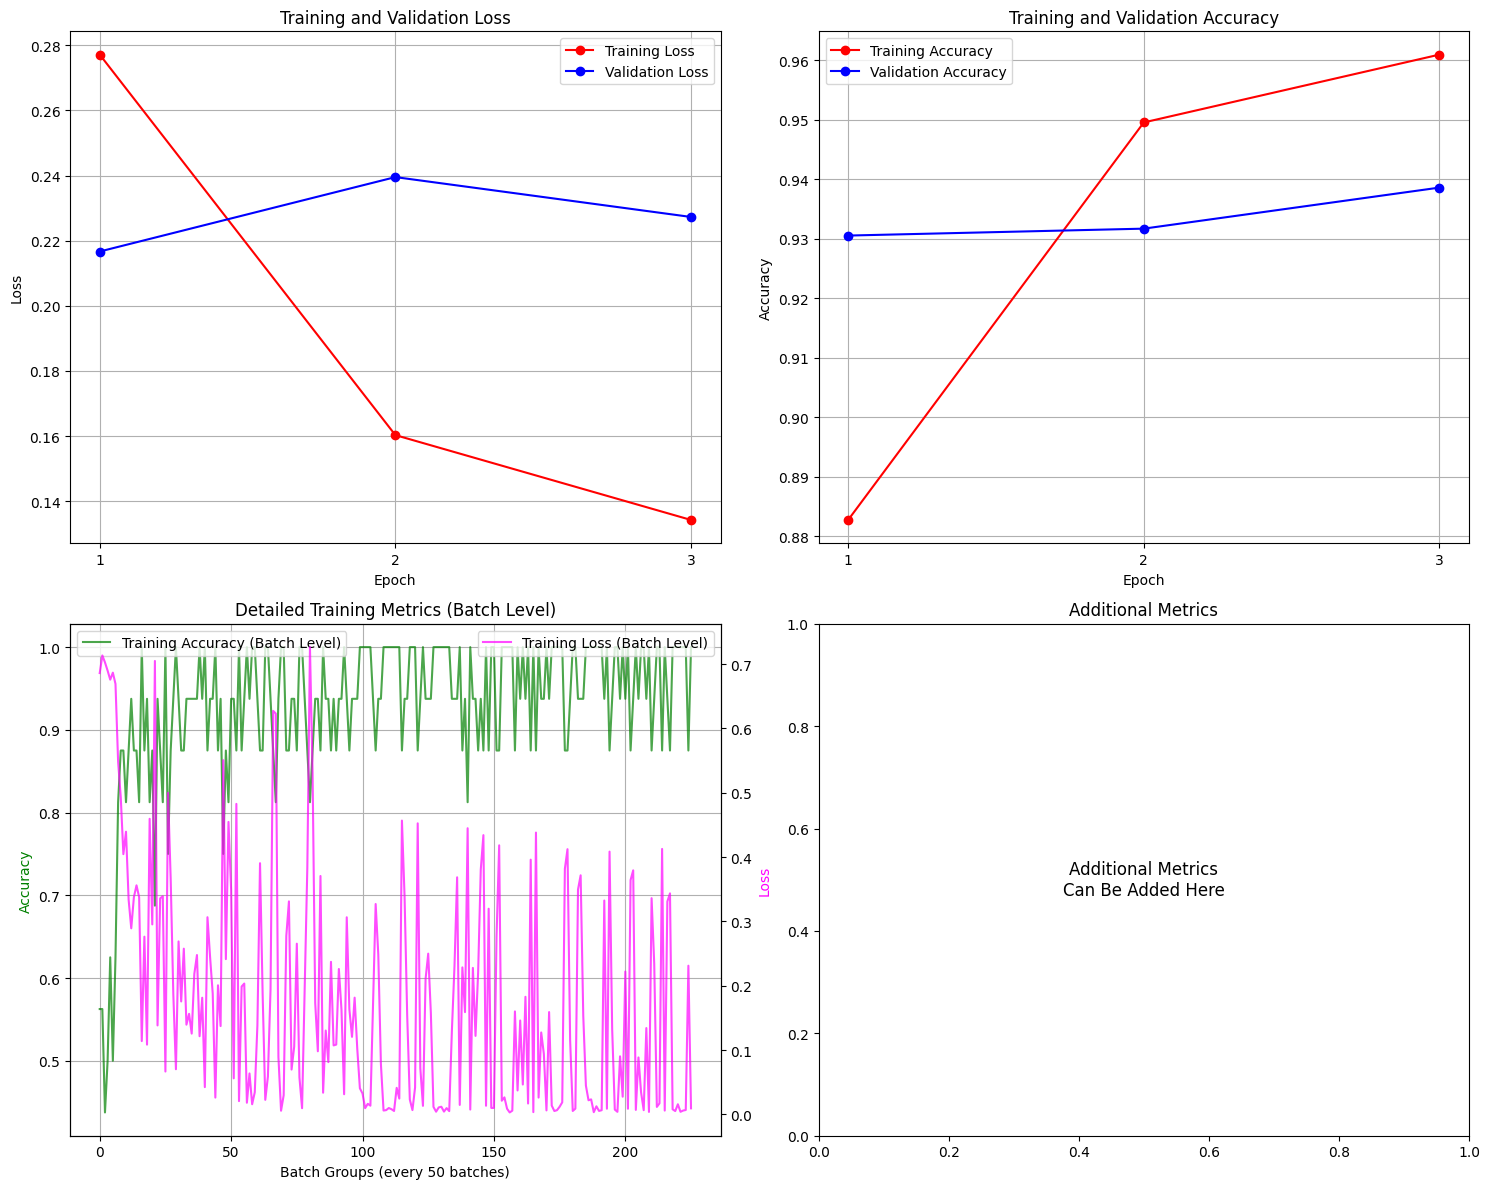

In [23]:
# Create epoch-wise training summary table
training_df = pd.DataFrame(training_stats)
print("\nTraining Summary Table:")
print("="*80)
print(f"{'Epoch':<6} {'Training Loss':<15} {'Validation Loss':<17} {'Accuracy':<10} {'F1':<10} {'Precision':<12} {'Recall':<10}")
print("="*80)
for _, row in training_df.iterrows():
    print(f"{row['epoch']:<6} {row['train_loss']:<15.6f} {row['val_loss']:<17.6f} {row['val_accuracy']:<10.6f} {row['val_f1']:<10.6f} {row['val_precision']:<12.6f} {row['val_recall']:<10.6f}")
print("="*80)

# Plot comprehensive training curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

epochs_range = list(range(1, len(train_losses) + 1))

# Plot 1: Training and Validation Loss
ax1.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
ax1.plot(epochs_range, val_losses, label='Validation Loss', color='blue', marker='o')
ax1.set_xticks(epochs_range)
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot 2: Training and Validation Accuracy
ax2.plot(epochs_range, train_accuracies, label='Training Accuracy', color='red', marker='o')
ax2.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='blue', marker='o')
ax2.set_xticks(epochs_range)
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)


# Plot 3: Detailed Training Metrics (Batch Level)
ax3.plot(batch_numbers, batch_train_accuracies, label='Training Accuracy (Batch Level)', color='green', alpha=0.7)
ax3_twin = ax3.twinx()
ax3_twin.plot(batch_numbers, batch_train_losses, label='Training Loss (Batch Level)', color='magenta', alpha=0.7)
ax3.set_title('Detailed Training Metrics (Batch Level)')
ax3.set_xlabel('Batch Groups (every 50 batches)')
ax3.set_ylabel('Accuracy', color='green')
ax3_twin.set_ylabel('Loss', color='magenta')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(True)

# Plot 4: Learning Rate Schedule (if you want to add this)
ax4.text(0.5, 0.5, 'Additional Metrics\nCan Be Added Here', 
         horizontalalignment='center', verticalalignment='center', 
         transform=ax4.transAxes, fontsize=12)
ax4.set_title('Additional Metrics')

plt.tight_layout()
plt.savefig('comprehensive_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# 9. Final test evaluation and classification report


Evaluating model on test set...


100%|██████████| 806/806 [01:49<00:00,  7.36it/s]



Test Results:
Test Accuracy: 0.9274
Test Precision: 0.9316
Test Recall: 0.9274
Test F1-Score: 0.9285

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.92      0.87      3463
    Positive       0.97      0.93      0.95      9426

    accuracy                           0.93     12889
   macro avg       0.90      0.93      0.91     12889
weighted avg       0.93      0.93      0.93     12889



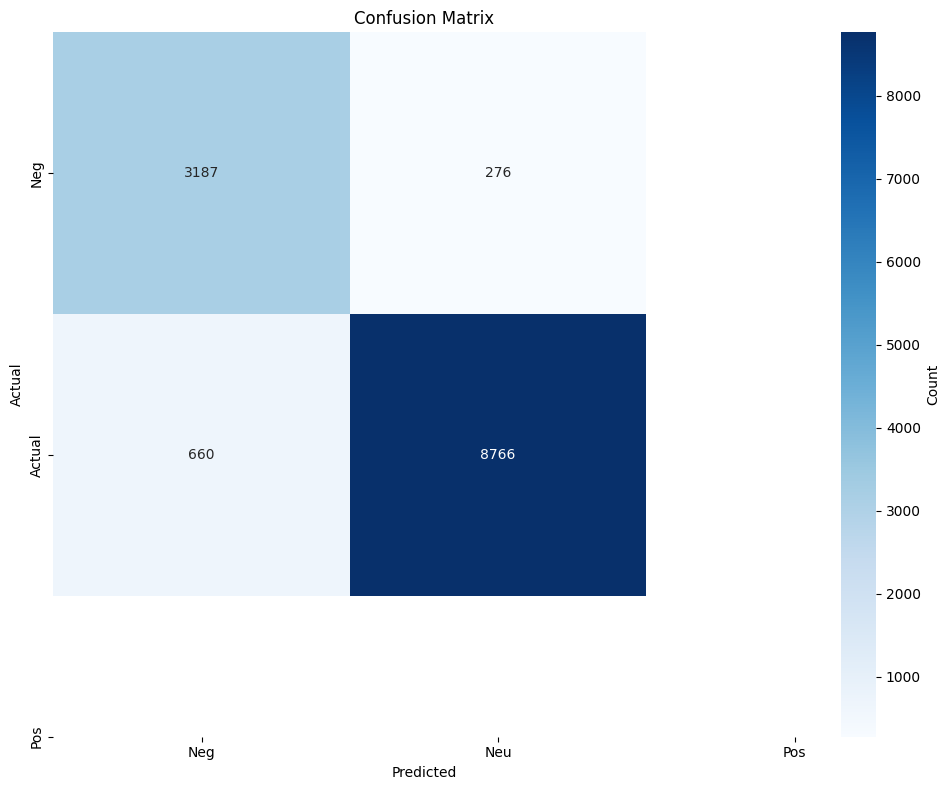


Final Evaluation:
eval_loss: 0.227299409326444
eval_accuracy: 0.927379936379859
eval_f1: 0.928532346246622
eval_precision: 0.931581860953012
eval_recall: 0.927379936379859
eval_runtime: 4427.7844 seconds
eval_samples_per_second: 2.911
eval_steps_per_second: 0.182
epoch: 3.0

Sample text: 'This product is amazing and works perfectly!'
Predicted sentiment: Positive

CONFIGURATION SUMMARY
Model: BERT
Tokenizer: BertTokenizer
Batch Size: 16
Learning Rate: 5e-6
Epochs: 3


In [24]:
# Load the best model for testing
model.load_state_dict(torch.load('best_model.pt'))

# Test the model
print("\nEvaluating model on test set...")
model.eval()
test_predictions = []
test_true_labels = []

for batch in tqdm(test_dataloader):
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)
    
    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask)
    
    logits = outputs.logits
    
    # Move predictions and labels to CPU
    predictions = torch.argmax(logits, dim=1).cpu().numpy()
    labels = b_labels.cpu().numpy()
    
    test_predictions.extend(predictions)
    test_true_labels.extend(labels)

# Calculate test metrics
test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted')
test_recall = recall_score(test_true_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted')

print("\nTest Results:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(test_true_labels, test_predictions, target_names=['Negative', 'Positive']))

# Create and plot confusion matrix
cm = confusion_matrix(test_true_labels, test_predictions)
plt.figure(figsize=(10, 8))

# Create confusion matrix plot
ax = plt.subplot(111)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Actual', 'Pos'],
            cbar_kws={'label': 'Count'})

# Adjust labels to match your image
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Add custom labels to match the image format
ax.set_xticklabels(['Neg', 'Neu', 'Pos'])
ax.set_yticklabels(['Neg', 'Actual', 'Pos'])

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Create final evaluation summary
final_eval = {
    'eval_loss': total_eval_loss / len(validation_dataloader) if 'total_eval_loss' in locals() else 0,
    'eval_accuracy': test_accuracy,
    'eval_f1': test_f1,
    'eval_precision': test_precision,
    'eval_recall': test_recall,
    'eval_runtime': total_training_time,
    'eval_samples_per_second': len(test_dataset) / total_training_time if total_training_time > 0 else 0,
    'eval_steps_per_second': len(test_dataloader) / total_training_time if total_training_time > 0 else 0,
    'epoch': epochs
}

print("\nFinal Evaluation:")
print(f"eval_loss: {final_eval['eval_loss']:.15f}")
print(f"eval_accuracy: {final_eval['eval_accuracy']:.15f}")
print(f"eval_f1: {final_eval['eval_f1']:.15f}")
print(f"eval_precision: {final_eval['eval_precision']:.15f}")
print(f"eval_recall: {final_eval['eval_recall']:.15f}")
print(f"eval_runtime: {final_eval['eval_runtime']:.4f} seconds")
print(f"eval_samples_per_second: {final_eval['eval_samples_per_second']:.3f}")
print(f"eval_steps_per_second: {final_eval['eval_steps_per_second']:.3f}")
print(f"epoch: {final_eval['epoch']:.1f}")


# Function to predict sentiment for new text
def predict_sentiment(text, model, tokenizer, device):
    encoded_dict = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    
    input_ids = encoded_dict['input_ids'].to(device)
    attention_mask = encoded_dict['attention_mask'].to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
    
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=1).item()
    
    return "Positive" if prediction == 1 else "Negative"

# Example usage
sample_text = "This product is amazing and works perfectly!"
sentiment = predict_sentiment(sample_text, model, tokenizer, device)
print(f"\nSample text: '{sample_text}'")
print(f"Predicted sentiment: {sentiment}")

print("\n" + "="*50)
print("CONFIGURATION SUMMARY")
print("="*50)
print(f"Model: BERT")
print(f"Tokenizer: BertTokenizer")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: 5e-6")
print(f"Epochs: {epochs}")
print("="*50)

# Plot Test Accuracy by Class

Per-class Accuracy:
Negative: 0.9203
Positive: 0.9300


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


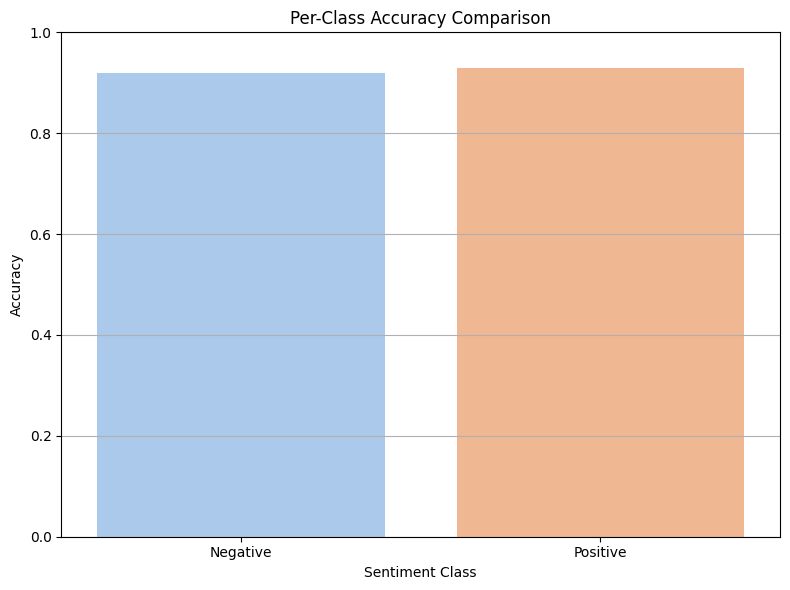

In [25]:
from collections import Counter

# Convert to numpy arrays
y_true = np.array(test_true_labels)
y_pred = np.array(test_predictions)

# Unique classes (0 = Negative/Neutral, 1 = Positive)
classes = [0, 1]
class_names = ['Negative', 'Positive']
class_accuracies = []

for cls in classes:
    # Get indexes of samples belonging to class `cls`
    idx = (y_true == cls)
    total = np.sum(idx)
    correct = np.sum(y_pred[idx] == cls)
    acc = correct / total if total > 0 else 0
    class_accuracies.append(acc)

print("Per-class Accuracy:")
for name, acc in zip(class_names, class_accuracies):
    print(f"{name}: {acc:.4f}")
    
plt.figure(figsize=(8, 6))
sns.barplot(x=class_names, y=class_accuracies, palette='pastel')
plt.ylim(0, 1.0)
plt.title('Per-Class Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Sentiment Class')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('per_class_accuracy_barplot.png', dpi=300)
plt.show()
